In [4]:
#dataset = https://www.kaggle.com/datasets/dipam7/student-grade-prediction

#importing libraries:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import kagglehub
from kagglehub import KaggleDatasetAdapter, dataset_download

In [5]:
#downloading dataset:
kagglehub.dataset_download('dipam7/student-grade-prediction')

100%|██████████| 7.16k/7.16k [00:00<00:00, 462kB/s]

Extracting files...


'C:\\Users\\Lenovo\\.cache\\kagglehub\\datasets\\dipam7\\student-grade-prediction\\versions\\1'

In [10]:
#importing dataset:
df = pd.read_csv(r'C:\Users\Lenovo\.cache\kagglehub\datasets\dipam7\student-grade-prediction\versions\1\student-mat.csv')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [17]:
#seeing only number based columns:
df.select_dtypes(include = 'number').columns

Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3'],
      dtype='object')

In [18]:
#defining what to predict we have to predict G3 as final grade so we will put it as our y:
x = df.select_dtypes(include = 'number').drop(columns = ['G3'])
y = df['G3']

In [20]:
#splitting data for training and testing:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

In [21]:
#making an ai model:
model = LinearRegression()

In [22]:
#training ai model:
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
#testing ai model by giving it testing data:
predictions = model.predict(x_test)

# **evaluating ai model**

Text(0, 0.5, 'predicted values')

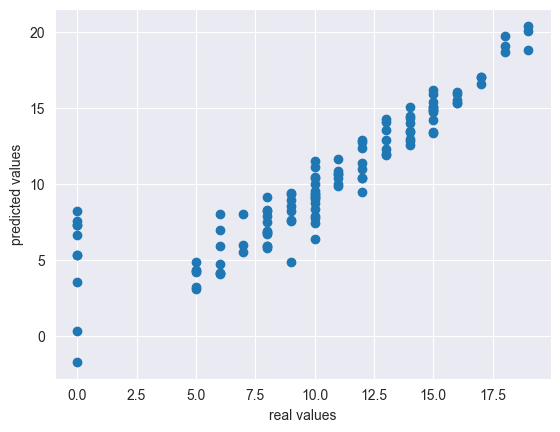

In [26]:
#scatter plot of real values vs predicted values:
plt.scatter(x = y_test, y = predictions)
plt.xlabel('real values')
plt.ylabel('predicted values')

<Axes: xlabel='G3', ylabel='Count'>

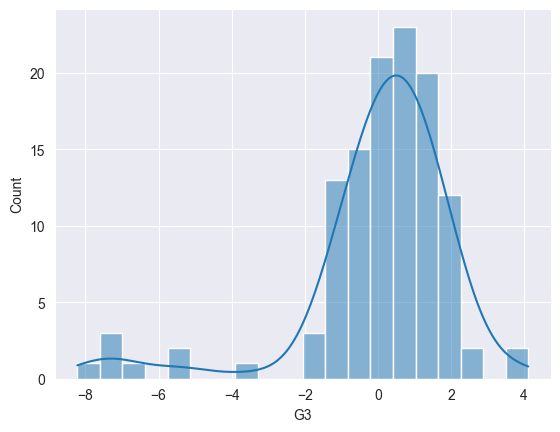

In [28]:
#histogram of residuals:
residuals = y_test - predictions
sns.histplot(residuals, kde = True)

In [45]:
#mae, rmse:
mae = metrics.mean_absolute_error(y_test, predictions)
rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
mae_percentage = (mae / y.mean()) * 100
rmse_percentage = (rmse / y.mean()) * 100
print(f'mae = {mae_percentage}')
print(f'rmse = {rmse_percentage}')

#ai model is not soo good

mae = 12.828550905662023
rmse = 19.883304339980445


# **Conclusion**

In [44]:
#what should be increased? what should be decreased?
df2 = pd.DataFrame(data = model.coef_, index = x.columns, columns = ['Coefficient'])
df2['Coefficient']

age          -0.181545
Medu          0.078652
Fedu         -0.187993
traveltime    0.188852
studytime    -0.149924
failures     -0.311482
famrel        0.355621
freetime     -0.042316
goout         0.134596
Dalc         -0.120951
Walc          0.022204
health        0.036379
absences      0.038738
G1            0.181662
G2            0.971373
Name: Coefficient, dtype: float64

In [ ]:
#increase = family time, travel time
#decrease = free time